# **Algoritmo  SIFT/SURF Pipeline visión estéreo por detección de características**



### **Que es vision estereo**
La vision estereo utiliza dos imagenes de la misma escena tomadas desde posiciones ligeramente distintas (camara izquierda y derecha). A partir de la diferencia aparente de posicion de un mismo punto en ambas imagenes, se estima la **disparidad**, y con ella, la profundidad.

### **Que son SIFT y SURF**
- **SIFT (Scale-Invariant Feature Transform)**: detecta puntos robustos a escala y rotacion, y describe su vecindad con un vector de 128 dimensiones.
- **SURF (Speeded-Up Robust Features)**: aproximacion mas rapida inspirada en SIFT, basada en Hessiano e imagenes integrales.



Relaciones clave:
$$d = x_L - x_R$$
$$Z = \frac{f \cdot B}{d}$$
donde $f$ es distancia focal (pixeles), $B$ es baseline (metros), $d$ disparidad y $Z$ profundidad.

In [1]:
!pip install rawpy

In [2]:
import os
import random
import rawpy
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
import cv2 as cv

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Las imágenes se cargan en escala de grises desde un formato `.raw`, se reescalan a 1024 pixeles para facilitar el procesamiento.



### **Uso de escala de grises**
Para SIFT/SURF  lo importante suele ser la estructura local de intensidad. Trabajar en gris reduce costo computacional y evita variaciones de color poco relevantes para la correspondencia geometrica.

### **RAW vs JPG**
- **RAW**: conserva mayor rango dinamico y menos procesamiento interno de camara. Ideal para analisis fino.
- **JPG**: comprimido y con perdidas; mas liviano, pero puede degradar detalles utiles para matching.



In [4]:
PATH = "/content/drive/MyDrive/baby"

@dataclass
class PipelineResult:
    name: str
    kp1_count: int
    kp2_count: int
    raw_matches: int
    good_matches: int
    inliers: int
    disparity_valid_ratio: float
    disparity_mean: float
    disparity_map: np.ndarray
    rect_left: np.ndarray
    rect_right: np.ndarray
    matches_vis: np.ndarray
    inlier_matches_vis: np.ndarray

def load_gray(path: str) -> np.ndarray:
    if str(path).lower().endswith(".raw"):
        try:
            with rawpy.imread(path) as raw:
                # Usar half_size para reducir resolución (mayor velocidad de proceso)
                rgb = raw.postprocess(half_size=True)
                img = cv.cvtColor(rgb, cv.COLOR_RGB2GRAY)
                # Escalar la imagen a un tamaño manejable (~1024px)
                h, w = img.shape
                scale = 1024.0 / max(w, h)
                if scale < 1.0:
                    img = cv.resize(img, (0,0), fx=scale, fy=scale)
                return img
        except Exception as e:
            raise RuntimeError(f"Error procesando RAW con rawpy {path}: {e}")

    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {path}")
    return img

In [5]:
img_paths = [
    os.path.join(PATH, "photo-20251016-214710.raw"),
    os.path.join(PATH, "photo-20251016-214659.raw")
]

imgs = [load_gray(path) for path in img_paths]

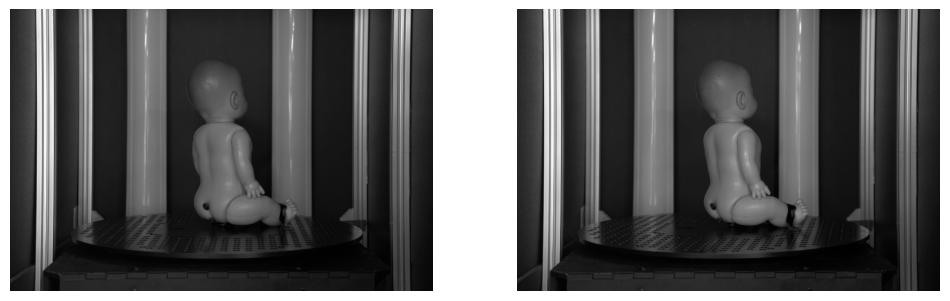

In [6]:
fig, axs = plt.subplots(1,len(imgs))
fig.set_size_inches(12, 5)
for i in range(len(imgs)):
    axs[i].imshow(imgs[i], cmap="gray")
    axs[i].axis("off")
plt.show()

## **Deteccion de Caracteristicas (SIFT/SURF)**
Encuentra puntos clave en cada imágen (esquinas, bordes, texturas).

Soporta los siguientes algoritmos:
* **SIFT** *(Scale-Invariante Feature Transform)*: Busca encontrar puntos que sean reconocibles sin importar la escala, rotación ni iluminación de la imágen. Hace esto mediante diferencia de gaussianas.

$$L(x,y,\sigma) = G(x,y,\sigma) * I(x,y)$$
$$D(x,y,\sigma) = L(x,y,k\sigma) - L(x,y,\sigma)$$

Luego asigna orientacion dominante para robustez a rotacion y construye un descriptor local de 128 componentes.


* **SURF** *(Speeded-Up Robust Features)*: Aproximación más rápida de SIFT que en lugar de usar filtros gaussianos usa filtros de cajas.

$$\mathbf{H}(x,\sigma) = \begin{bmatrix}L_{xx}(x,\sigma) & L_{xy}(x,\sigma)\\L_{xy}(x,\sigma) & L_{yy}(x,\sigma)\end{bmatrix}$$
$$\det(\mathbf{H}) = L_{xx}L_{yy} - (wL_{xy})^2$$

Por diseno, SURF suele ser mas rapido que SIFT, aunque depende de la implementacion disponible.


La decisión entre usar un algoritmo u otro depende de los requerimientos del sistema a implementar dado que SIFT es más costoso computacionalmente pero es la alternativa más robusta.

Para este caso específico dado que no tenemos limitaciones de tiempo, se usa **SIFT**, aunque se deja implementado para fácilmente emplear SURF.

`detect_and_describe` retornará para cada imágen un punto y su descriptor, el cual corresponde a un vector numérico que lo describe para poder compararlo entre imágenes.

In [7]:
def create_detector(method: str, **kwargs):
    method = method.upper()
    if method == "SIFT":
        # contrastThreshold más bajo => más puntos, incluyendo bajo contraste
        return cv.SIFT_create(
            contrastThreshold=kwargs.get('sift_contrastThreshold', 0.04),
            edgeThreshold=kwargs.get('sift_edgeThreshold', 10)
        )

    if method == "SURF":
        if not hasattr(cv, "xfeatures2d"):
            raise RuntimeError(
                "OpenCV no tiene xfeatures2d. Instala opencv-contrib-python."
            )
        if not hasattr(cv.xfeatures2d, "SURF_create"):
            raise RuntimeError(
                "Tu build de OpenCV no expone SURF_create(). "
                "Necesitas una build con xfeatures2d/nonfree."
            )
        # hessianThreshold más bajo => más puntos
        return cv.xfeatures2d.SURF_create(
            hessianThreshold=kwargs.get('surf_hessianThreshold', 400),
            nOctaves=kwargs.get('surf_nOctaves', 4),
            nOctaveLayers=kwargs.get('surf_nOctaveLayers', 3),
            extended=kwargs.get('surf_extended', False),
            upright=kwargs.get('surf_upright', False)
        )

    raise ValueError("Método no soportado. Usa SIFT o SURF.")


def detect_and_describe(img1: np.ndarray, img2: np.ndarray, method: str, **kwargs):
    detector = create_detector(method, **kwargs)
    kp1, des1 = detector.detectAndCompute(img1, None)
    kp2, des2 = detector.detectAndCompute(img2, None)

    if des1 is None or des2 is None or len(kp1) < 8 or len(kp2) < 8:
        raise RuntimeError(f"{method}: no hay suficientes features para continuar.")

    return kp1, des1, kp2, des2

In [8]:
kp1, des1, kp2, des2 = detect_and_describe(*imgs, method="SIFT")

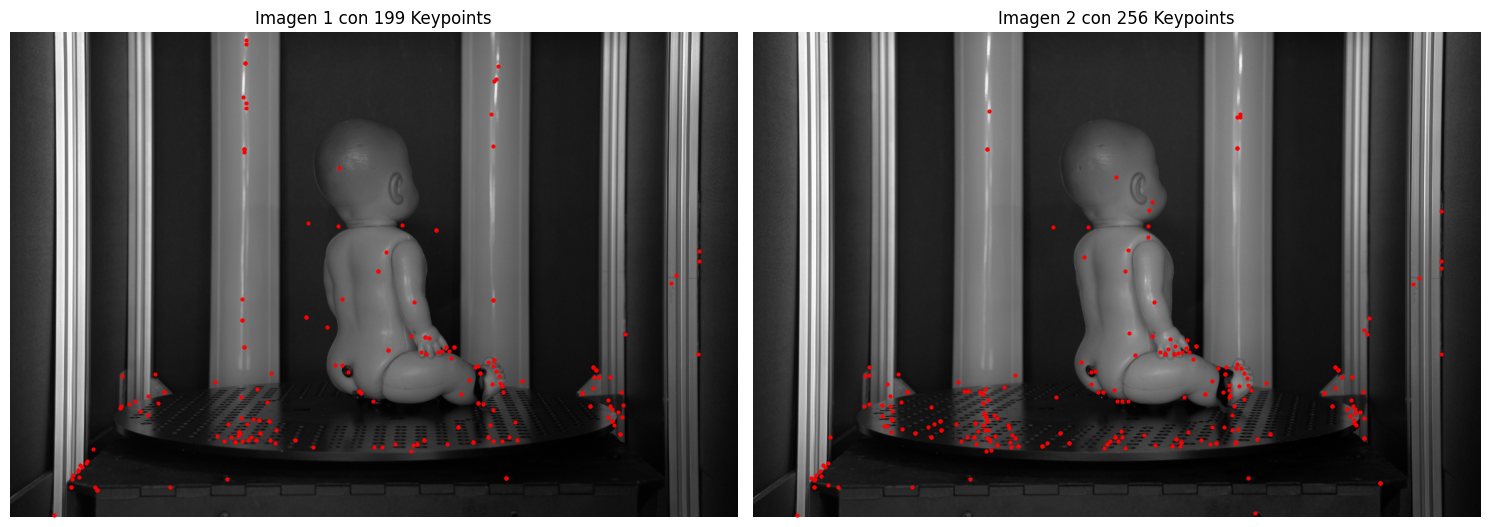

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Plot keypoints on the first image
axs[0].imshow(imgs[0], cmap='gray')
axs[0].set_title(f'Imagen 1 con {len(kp1)} Keypoints')
for kp in kp1:
    axs[0].plot(kp.pt[0], kp.pt[1], 'ro', markersize=2) # 'ro' for red circle
axs[0].axis('off')

# Plot keypoints on the second image
axs[1].imshow(imgs[1], cmap='gray')
axs[1].set_title(f'Imagen 2 con {len(kp2)} Keypoints')
for kp in kp2:
    axs[1].plot(kp.pt[0], kp.pt[1], 'ro', markersize=2) # 'ro' for red circle
axs[1].axis('off')

plt.tight_layout()
plt.show()

**Matching de Caracteristicas (Emparejamiento)**

Ahora que se tiene un vector de los puntos de la imágenes, se tiene que correlacionar cual punto de la imágen 1 corresponde a la imágen 2.  usando un BFMatcher (fuerza bruta). Aplica el ratio test de Lowe: solo acepta un match si el mejor candidato es significativamente mejor que el segundo mejor (ratio < 0.75). Esto elimina matches ambiguos.

## **BFMatcher**
El **Brute-Force Matcher** compara cada descriptor de la imagen izquierda contra todos los de la derecha con una metrica de distancia (L2 para SIFT/SURF).

### **KNN Matching**
Para cada descriptor, se buscan los dos vecinos mas cercanos: $d_1$ y $d_2$.

### **Ratio Test de Lowe**
Se acepta una correspondencia si:
$$\frac{d_1}{d_2} < 0.75$$
Esto elimina coincidencias ambiguas y reduce falsos positivos.

In [10]:
def knn_ratio_match(des1, des2, ratio=0.75):
    # SIFT/SURF usan descriptores float => NORM_L2
    bf = cv.BFMatcher(cv.NORM_L2, crossCheck=False)
    knn = bf.knnMatch(des1, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good.append(m)

    return knn, good

def draw_matches(img1, kp1, img2, kp2, matches, max_draw=80):
    draw = matches[:max_draw]
    return cv.drawMatches(
        img1, kp1, img2, kp2, draw, None,
        flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )


In [11]:
raw_knn, good = knn_ratio_match(des1, des2, ratio=0.75)

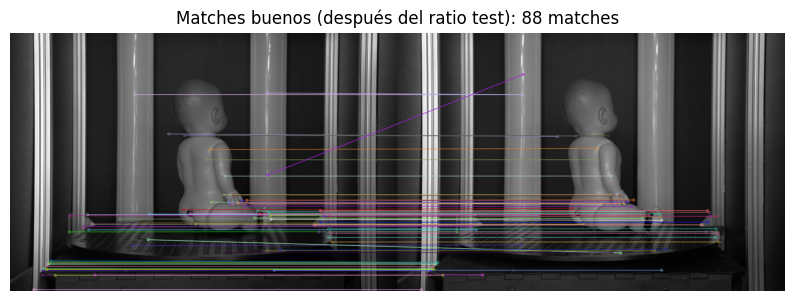

In [12]:
matches_vis = draw_matches(imgs[0], kp1, imgs[1], kp2, good)
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(matches_vis, cv.COLOR_BGR2RGB))
plt.title(f'Matches buenos (después del ratio test): {len(good)} matches')
plt.axis('off')
plt.show()

Como se puede observar, una parte considerable de las características se enfocan en la superficie sobre la que se ubica el objeto de muestra, esto porque presenta una textura mucho más rica (gracias a los agujeros y las sombras) por lo que no se tiene tanto detalle sobre otras regiones de la imagen.

Otra parte notable es que una de las características que hizo match relacionó un reflejo de la lámpara de la derecha de la imágen 1 con un reflejo en la lámpara de la izquierda. Esto tendrá una mayor incidencia a futuro como se podrá observar más adelante.

 #  **Estimación geométrica**

 Con los matches buenos, estima la matriz fundamental F, que describe la geometría entre las dos cámaras (¿cómo están posicionadas una respecto a la otra?). Usa RANSAC para descartar matches incorrectos (outliers) y quedarse solo con los inliers consistentes.

In [13]:
def fundamental_ransac(kp1, kp2, matches):
    if len(matches) < 8:
        raise RuntimeError("No hay suficientes matches para estimar F.")

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    F, mask = cv.findFundamentalMat(
        pts1, pts2, cv.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99
    )

    if F is None or mask is None:
        raise RuntimeError("No se pudo estimar la matriz fundamental.")

    mask = mask.ravel().astype(bool)
    inlier_matches = [m for m, keep in zip(matches, mask) if keep]

    pts1_in = pts1[mask]
    pts2_in = pts2[mask]

    if len(pts1_in) < 8:
        raise RuntimeError("Muy pocos inliers después de RANSAC.")

    return F, mask, inlier_matches, pts1_in, pts2_in


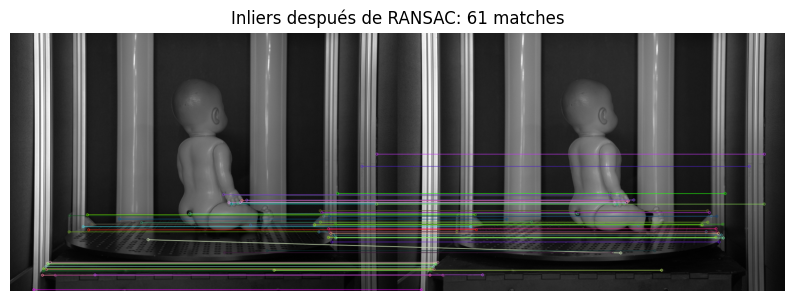

In [14]:
F, mask, inlier_matches, pts1_in, pts2_in = fundamental_ransac(kp1, kp2, good)
inlier_matches_vis = draw_matches(imgs[0], kp1, imgs[1], kp2, inlier_matches)
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(inlier_matches_vis, cv.COLOR_BGR2RGB))
plt.title(f'Inliers después de RANSAC: {len(inlier_matches)} matches')
plt.axis('off')
plt.show()

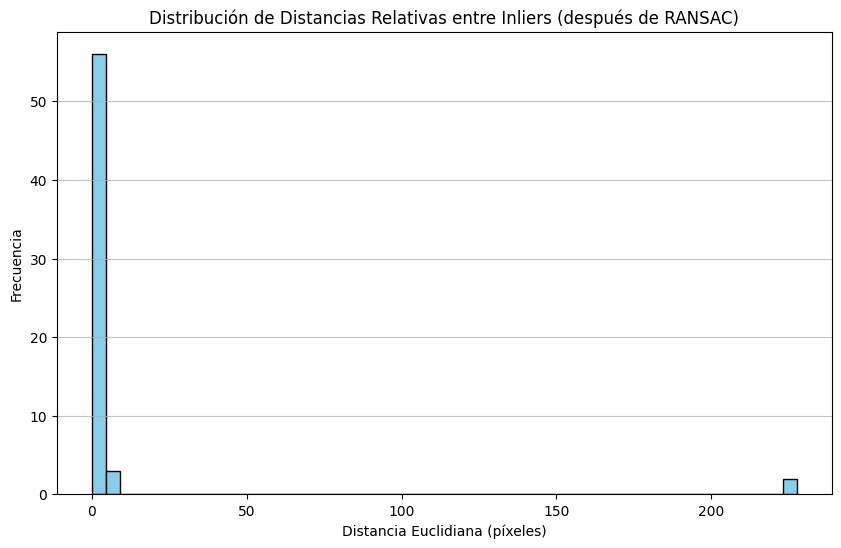

In [15]:
distances = np.linalg.norm(pts1_in - pts2_in, axis=1)

plt.figure(figsize=(10, 6))
plt.hist(distances, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Distancias Relativas entre Inliers (después de RANSAC)')
plt.xlabel('Distancia Euclidiana (píxeles)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

##  **Rectificacion Estereo**

Transforma ambas imágenes para que las líneas epipolares queden horizontales. Esto es clave porque el algoritmo de disparidad solo funciona bien cuando los píxeles correspondientes están en la misma fila en ambas imágenes. Se hace sin calibración previa de cámara (uncalibrated).

Rectificar significa transformar ambas imagenes para que sus lineas epipolares queden alineadas horizontalmente.

Consecuencia practica: la busqueda de correspondencia se reduce de 2D a 1D (misma fila), simplificando y estabilizando el calculo de disparidad.

En las visualizaciones, las lineas verdes horizontales ayudan a verificar visualmente esa alineacion antes y despues de rectificar.

In [16]:
def rectify_uncalibrated(img1, img2, pts1, pts2, F):
    h, w = img1.shape[:2]

    ok, H1, H2 = cv.stereoRectifyUncalibrated(
        np.float32(pts1), np.float32(pts2), F, imgSize=(w, h)
    )
    if not ok:
        raise RuntimeError("No se pudo rectificar el par de imágenes.")

    rect1 = cv.warpPerspective(img1, H1, (w, h))
    rect2 = cv.warpPerspective(img2, H2, (w, h))
    return rect1, rect2


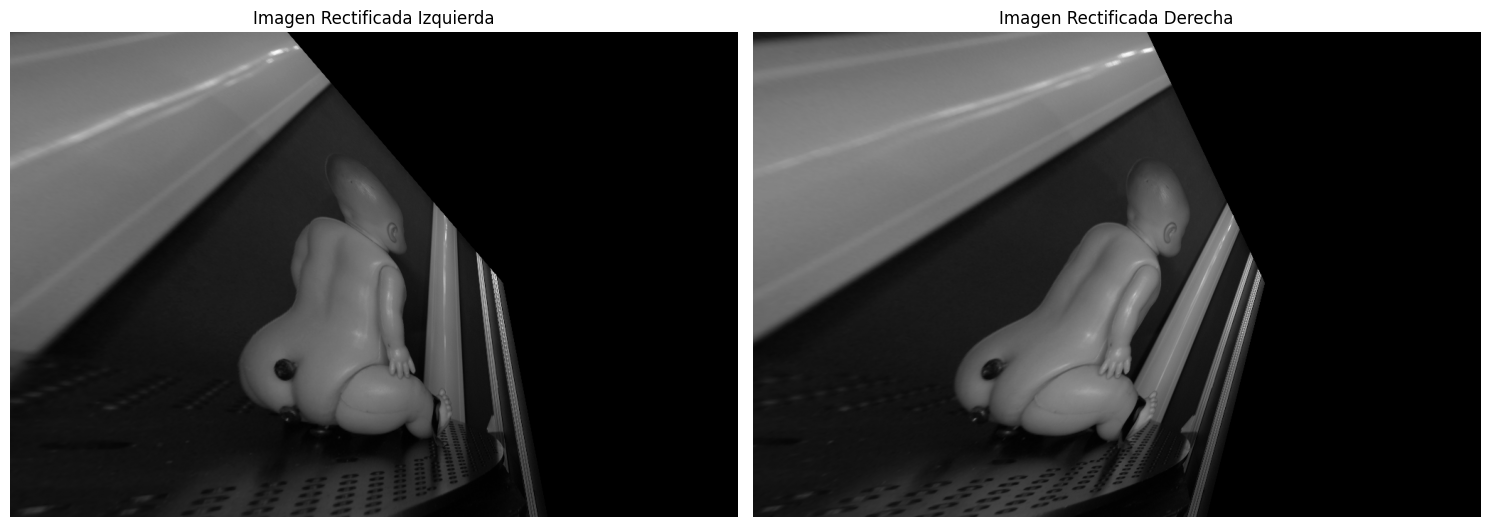

In [17]:
rect1, rect2 = rectify_uncalibrated(imgs[0], imgs[1], pts1_in, pts2_in, F)

fig, axs = plt.subplots(1, 2, figsize=(15, 7))
axs[0].imshow(rect1, cmap='gray')
axs[0].set_title('Imagen Rectificada Izquierda')
axs[0].axis('off')
axs[1].imshow(rect2, cmap='gray')
axs[1].set_title('Imagen Rectificada Derecha')
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [18]:
def sample_keypoints_grid(img, kp, des, rows=4, cols=4, n_per_cell=15):
    h, w = img.shape
    kp_sel, des_sel = [], []
    for r in range(rows):
        for c in range(cols):
            y0, y1 = r*h//rows, (r+1)*h//rows
            x0, x1 = c*w//cols, (c+1)*w//cols
            idx = [i for i, k in enumerate(kp)
                   if x0 <= k.pt[0] < x1 and y0 <= k.pt[1] < y1]
            # Ordenar por respuesta (calidad del keypoint)
            idx = sorted(idx, key=lambda i: kp[i].response, reverse=True)[:n_per_cell]
            kp_sel.extend([kp[i] for i in idx])
            des_sel.extend([des[i] for i in idx])
    return kp_sel, np.array(des_sel) if des_sel else np.empty((0, des.shape[1]))

# Aplicar grilla ANTES de matchear
kp1_1, des1_1 = sample_keypoints_grid(imgs[0], kp1, des1)
kp2_1, des2_1 = sample_keypoints_grid(imgs[1], kp2, des2)

raw_knn_1, good_1 = knn_ratio_match(des1_1, des2_1, ratio=0.75)

## **Emparejamiento con Keypoints Muestreados en Cuadrícula**
Ahora que hemos filtrado los keypoints por una cuadrícula, volvemos a realizar el emparejamiento y visualizamos los "buenos" matches.

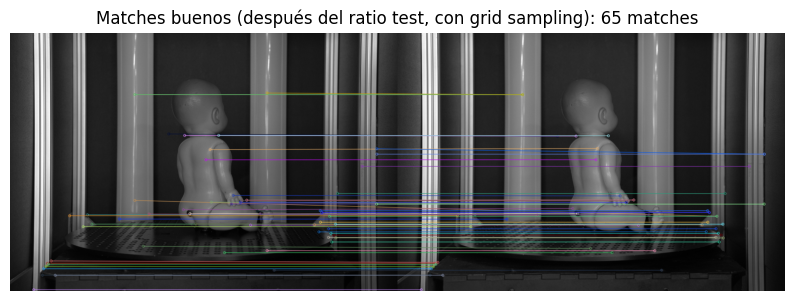

In [19]:
matches_vis_grid_sampled = draw_matches(imgs[0], kp1_1, imgs[1], kp2_1, good_1)
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(matches_vis_grid_sampled, cv.COLOR_BGR2RGB))
plt.title(f'Matches buenos (después del ratio test, con grid sampling): {len(good_1)} matches')
plt.axis('off')
plt.show()

## **Estimación Geométrica (RANSAC) con Keypoints Muestreados en Cuadrícula**

Con los matches obtenidos a partir de los keypoints muestreados en cuadrícula, procedemos a estimar la matriz fundamental y a filtrar los inliers utilizando RANSAC.

Inliers después de RANSAC (con grid sampling): 53


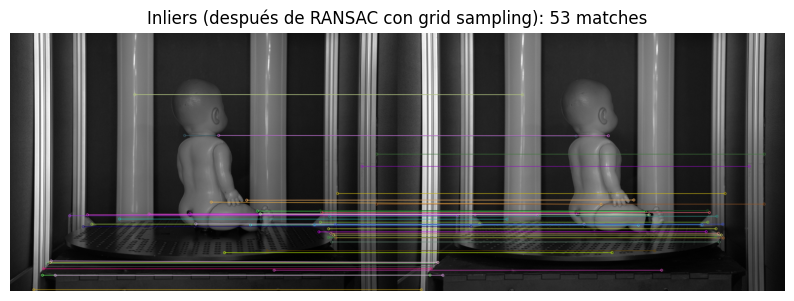

In [20]:
F_grid, mask_grid, inlier_matches_grid, pts1_in_grid, pts2_in_grid = fundamental_ransac(kp1_1, kp2_1, good_1)

print(f"Inliers después de RANSAC (con grid sampling): {len(inlier_matches_grid)}")

inlier_matches_grid_vis = draw_matches(imgs[0], kp1_1, imgs[1], kp2_1, inlier_matches_grid)
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(inlier_matches_grid_vis, cv.COLOR_BGR2RGB))
plt.title(f'Inliers (después de RANSAC con grid sampling): {len(inlier_matches_grid)} matches')
plt.axis('off')
plt.show()

###  **Rectificación (con Keypoints Muestreados en Cuadrícula**

Ahora vamos a rectificar las imágenes utilizando la matriz fundamental (`F_grid`) y los inliers (`pts1_in_grid`, `pts2_in_grid`) obtenidos después de RANSAC con los keypoints muestreados en cuadrícula. Esto preparará las imágenes para la estimación de disparidad.

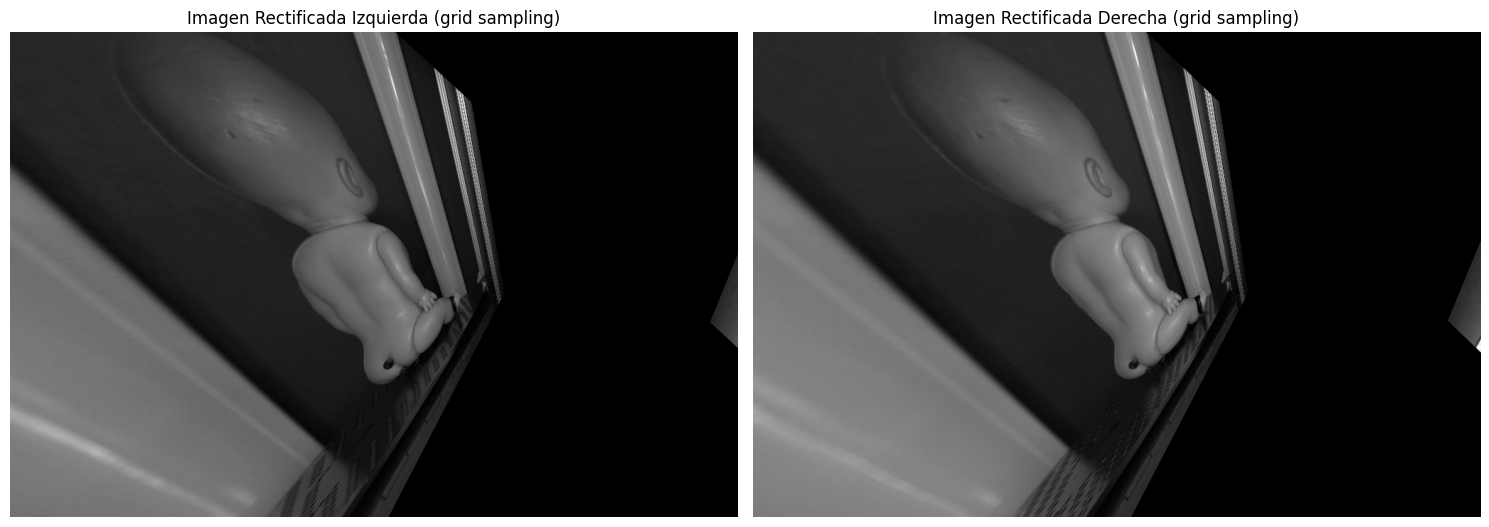

In [21]:
rect1_grid, rect2_grid = rectify_uncalibrated(imgs[0], imgs[1], pts1_in_grid, pts2_in_grid, F_grid)

fig, axs = plt.subplots(1, 2, figsize=(15, 7))
axs[0].imshow(rect1_grid, cmap='gray')
axs[0].set_title('Imagen Rectificada Izquierda (grid sampling)')
axs[0].axis('off')
axs[1].imshow(rect2_grid, cmap='gray')
axs[1].set_title('Imagen Rectificada Derecha (grid sampling)')
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [22]:
def crop_valid_region(rect1, rect2):
    # Máscara de píxeles no negros en ambas imágenes
    mask1 = rect1 > 0
    mask2 = rect2 > 0
    valid = mask1 & mask2

    # Filas y columnas que tienen al menos 50% de píxeles válidos
    row_valid = np.mean(valid, axis=1) > 0.5
    col_valid = np.mean(valid, axis=0) > 0.5

    rows = np.where(row_valid)[0]
    cols = np.where(col_valid)[0]

    if len(rows) == 0 or len(cols) == 0:
        return rect1, rect2  # No recortar si no hay región válida

    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]

    return rect1[r0:r1, c0:c1], rect2[r0:r1, c0:c1]


## **Cálculo del Mapa de Disparidad (con Keypoints Muestreados en Cuadrícula)**

Ahora calculamos el mapa de disparidad utilizando las imágenes rectificadas (`rect1_grid`, `rect2_grid`), que ya tienen las líneas epipolares alineadas. Esto nos permitirá visualizar la profundidad de la escena.

In [23]:
def compute_disparity_sgbm(rect1: np.ndarray, rect2: np.ndarray) -> np.ndarray:
    # numDisparities debe ser múltiplo de 16
    min_disp = 0
    num_disp = 16 * 8
    block_size = 5

    matcher = cv.StereoSGBM_create(
        minDisparity=min_disp,
        numDisparities=num_disp,
        blockSize=block_size,
        P1=8 * 1 * block_size * block_size,
        P2=32 * 1 * block_size * block_size,
        disp12MaxDiff=1,
        uniquenessRatio=10,
        speckleWindowSize=100,
        speckleRange=32,
        preFilterCap=63,
        mode=cv.STEREO_SGBM_MODE_SGBM_3WAY
    )

    disparity = matcher.compute(rect1, rect2).astype(np.float32) / 16.0
    return disparity


def disparity_stats(disparity: np.ndarray):
    valid = disparity > 0
    valid_ratio = float(np.mean(valid))
    mean_disp = float(np.mean(disparity[valid])) if np.any(valid) else 0.0
    return valid_ratio, mean_disp


def normalize_for_display(disparity: np.ndarray) -> np.ndarray:
    disp = disparity.copy()
    valid = disp > 0
    if not np.any(valid):
        return np.zeros_like(disp, dtype=np.uint8)

    dmin = np.min(disp[valid])
    dmax = np.max(disp[valid])
    if dmax - dmin < 1e-6:
        return np.zeros_like(disp, dtype=np.uint8)

    norm = np.zeros_like(disp, dtype=np.float32)
    norm[valid] = (disp[valid] - dmin) / (dmax - dmin)
    return (norm * 255).astype(np.uint8)


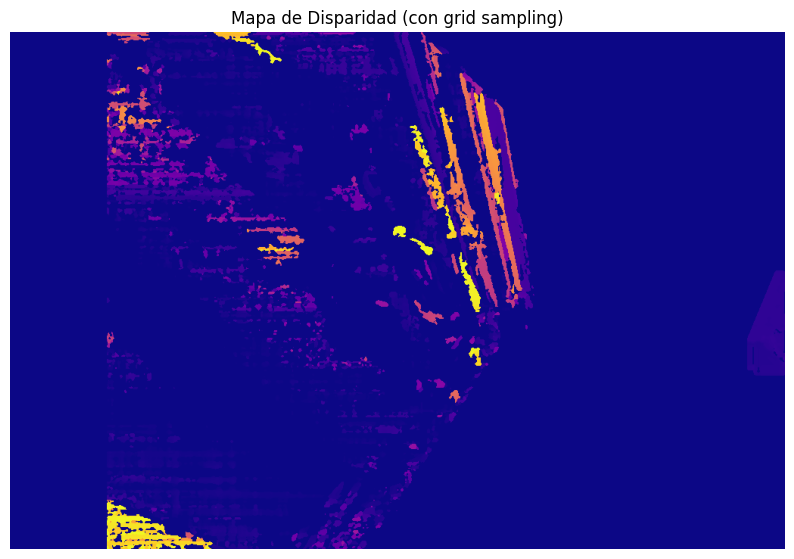

In [24]:
disparity_grid = compute_disparity_sgbm(rect1_grid, rect2_grid)
disp_vis_grid = normalize_for_display(disparity_grid)

plt.figure(figsize=(10, 8))
plt.imshow(disp_vis_grid, cmap='plasma')
plt.title('Mapa de Disparidad (con grid sampling)')
plt.axis('off')
plt.show()